## Project: Predict if someone has an Imaginary Companion
## Author: Jeet Sarkar
## Date: 01-06-2026

### This is my first machine learning project where I try to predict if people have Imaginary Companions based on their psychological scores. 

In [45]:
!pip freeze > requirements.txt

In [34]:
# Step 1: Importing all the libraries I need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score

# For XGBoost (needs to be installed separately)
import xgboost as xgb

# To ignore warning messages (makes output cleaner)
import warnings
warnings.filterwarnings('ignore')

In [72]:
# Step 2: Load the dataset
df = pd.read_csv(r"D:\Dataset\IC_cleaned_data.csv")

In [3]:
# Step 3: Exploratory Data Analysis
df.head()

,ID,age,gender,robotInteraction,imaginary_companions,imaginary_companion_status,loneliness,affectional,instrumental,tire,autonomy,depression,anxity,stress
0,5,24,male,4,No,never,48,44.0,47.0,10.0,6.0,11,11.0,38.0
1,6,23,female,4,Yes,current,49,43.0,41.0,7.0,3.0,6,5.0,21.0
2,7,22,male,4,No,never,31,44.0,51.0,3.0,0.0,7,4.0,14.0
3,8,22,male,7,Yes,past,43,30.0,41.0,9.0,2.0,7,9.0,27.0
4,9,22,male,4,No,never,34,35.0,42.0,3.0,2.0,1,1.0,7.0


In [4]:
df.tail()

,ID,age,gender,robotInteraction,imaginary_companions,imaginary_companion_status,loneliness,affectional,instrumental,tire,autonomy,depression,anxity,stress
149,156,19,male,10,Yes,past,51,19.0,33.0,11.0,8.0,6,10.0,35.0
150,157,19,male,6,No,never,31,40.0,53.0,10.0,1.0,8,12.0,31.0
151,158,19,female,7,Yes,past,49,37.0,41.0,7.0,3.0,9,12.0,31.0
152,159,19,female,6,Yes,past,34,28.0,35.0,8.0,8.0,7,5.0,28.0
153,160,19,female,7,No,never,29,57.0,58.0,12.0,5.0,5,10.0,32.0


#### *Columns Meanings*
##### 1. loneliness: Loneliness score (Higher scores mean greater feelings of isolation)
##### 2. affectional: Measuring the individual's perceived affectional support system. 
##### 3. tire: Tracking fatigue or physical/mental tiredness
##### 4. autonomy: Individual's sense of autonomy or self-governance.
##### 5. depression: Individual's depression tracking indicator.
##### 6. anxity: Individual's anxiety indicator.
##### 7. stress: Individual's stress level indicator.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          154 non-null    int64  
 1   age                         154 non-null    int64  
 2   gender                      153 non-null    object 
 3   robotInteraction            154 non-null    int64  
 4   imaginary_companions        154 non-null    object 
 5   imaginary_companion_status  154 non-null    object 
 6   loneliness                  154 non-null    int64  
 7   affectional                 153 non-null    float64
 8   instrumental                153 non-null    float64
 9   tire                        152 non-null    float64
 10  autonomy                    152 non-null    float64
 11  depression                  154 non-null    int64  
 12  anxity                      152 non-null    float64
 13  stress                      146 non

In [6]:
missing_values= df.isnull().sum()
missing_values

ID                            0
age                           0
gender                        1
robotInteraction              0
imaginary_companions          0
imaginary_companion_status    0
loneliness                    0
affectional                   1
instrumental                  1
tire                          2
autonomy                      2
depression                    0
anxity                        2
stress                        8
dtype: int64

In [7]:
# Step 4: Data Preprocessing

# For gender (categorical), use the most common value (mode)
mode_gender = df['gender'].mode()[0]
df['gender']= df['gender'].fillna(mode_gender)                      

# For numbers, use average (mean) or median
mean_affection= df['affectional'].mean()                            
df['affectional']= df['affectional'].fillna(mean_affection)

mean_instrumental= df['instrumental'].mean()
df['instrumental']= df['instrumental'].fillna(mean_instrumental)

mean_tire= df['tire'].mean()
df['tire']= df['tire'].fillna(mean_tire)

mean_autonomy= df['autonomy'].mean()     
df['autonomy']= df['autonomy'].fillna(mean_autonomy)

mean_anxity= df['anxity'].mean()
df['anxity']= df['anxity'].fillna(mean_anxity)

# For stress, I used median because it had outliers
median_stress= df['stress'].median()
df['stress']= df['stress'].fillna(median_stress)

# Check if all missing values are gone
filled_values= df.isnull().sum()
filled_values

ID                            0
age                           0
gender                        0
robotInteraction              0
imaginary_companions          0
imaginary_companion_status    0
loneliness                    0
affectional                   0
instrumental                  0
tire                          0
autonomy                      0
depression                    0
anxity                        0
stress                        0
dtype: int64

In [8]:
# Converting categorical variables to numeric using one-hot encoding
df= pd.get_dummies(df, columns= ['gender'])
# Remove columns I don't need
df.drop(['imaginary_companion_status', 'ID'], axis=1, inplace=True) 

In [9]:
# Step 5: Split fesutures (X) and target (y)
X= df.drop('imaginary_companions', axis=1)   # Features (what I use to predict)
y= df['imaginary_companions']                # Target (what I want to predict)

In [10]:
# Convert target to numbers (Yes=1, No=0)
le = LabelEncoder()
y = le.fit_transform(y)

In [11]:
# Step 6: Split into training and testing sets
# Train set: 80% of data to teach the model
# Test set: 20% of data to test how well it learned
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42, stratify=y )
print(f"Data split:-")
print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

Data split:-
Training set: 123 samples
Testing set: 31 samples


In [12]:
# Step 7: Scale the features (important for some models)
# This makes all features have the same scale (like converting to percentages)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Learn scaling from training data
X_test_scaled = scaler.transform(X_test)  # Apply same scaling to test data

## MODEL 1: LOGISTIC REGRESSION

In [13]:
# I'm using GridSearchCV to find the best parameters automatically
# Instead of guessing, it tries different combinations

# Parameters I want to try
param_grid_lr = {'C': [0.1,1,5,10,50,10],               # Regularization strength (smaller = more regularization)
                 'penalty': ['l1','l2'],            # Type of regularization
                 'solver': ['lbfgs', 'liblinear']}  # Algorithm to use

# Trying different parameter combinations...
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid_lr,
    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42),  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1)  # Use all CPU cores for speed

# Train the model with grid search
lr_grid.fit(X_train_scaled, y_train)

print(f"Best parameters found: {lr_grid.best_params_}")
print(f"Best cross-validation score: {lr_grid.best_score_:.3f}")

# Get the best model
best_lr = lr_grid.best_estimator_

# Make predictions
y_pred_lr = best_lr.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Test accuracy: {lr_accuracy:.3f}")

Best parameters found: {'C': 5, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation score: 0.636
Test accuracy: 0.677


## MODEL 2: RANDOM FOREST

In [14]:
# Parameters I want to try
param_grid_rf = {
    'n_estimators': [50, 100],  # Number of trees
    'max_depth': [5, 10, None],  # How deep each tree can grow
    'min_samples_split': [2, 5],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2]    # Minimum samples in a leaf node
}

# Trying different parameter combinations...
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train the model with grid search
rf_grid.fit(X_train_scaled, y_train)

print(f"Best parameters found: {rf_grid.best_params_}")
print(f"Best cross-validation score: {rf_grid.best_score_:.3f}")

# Get the best model
best_rf = rf_grid.best_estimator_

# Make predictions
y_pred_rf = best_rf.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Test accuracy: {rf_accuracy:.3f}")


Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation score: 0.683
Test accuracy: 0.581


## MODEL 3: GRADIENT BOOSTING

In [15]:
param_grid_gb = {'n_estimators': [100, 200],
                 'learning_rate': [0.05, 0.1, 0.2], # How fast the model learns
                 'max_depth': [3, 4, 5],          # Tree depth
                 'subsample': [0.8, 1.0]}      # Fraction of data to use for each tree

# Trying different parameter combinations...
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train the model with grid search
gb_grid.fit(X_train_scaled, y_train)

print(f"Best parameters found: {gb_grid.best_params_}")
print(f"Best cross-validation score: {gb_grid.best_score_:.3f}")

# Get the best model
best_gb = gb_grid.best_estimator_

# Make predictions
y_pred_gb = best_gb.predict(X_test_scaled)
gb_accuracy = accuracy_score(y_test, y_pred_gb)

print(f"Test accuracy: {gb_accuracy:.3f}")

Best parameters found: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation score: 0.667
Test accuracy: 0.548


## MODEL 5: XGBOOST

In [21]:
# For XGBoost, I'll do a two-step approach 
# Step 1: Try random combinations to get an idea
# Step 2: Focus on promising areas

#Step 1: Trying random combinations...

# Random search parameters
param_random = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.02, 0.05],
    'subsample': [0.6, 0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}


xgb_random = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_random,
    n_iter=20,  # Try 20 random combinations
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_scaled, y_train)

print(f"Best from random search: {xgb_random.best_params_}")

# Step 2: Fine-tune around the best parameters
best = xgb_random.best_params_
param_fine = {
    'n_estimators': [best['n_estimators'] - 50, best['n_estimators'], best['n_estimators'] + 50],
    'max_depth': [best['max_depth'] - 1, best['max_depth'], best['max_depth'] + 1],
    'learning_rate': [best['learning_rate'] * 0.5, best['learning_rate'], best['learning_rate'] * 1.5],
    'subsample': [max(0.6, best['subsample'] - 0.1), best['subsample'], min(1.0, best['subsample'] + 0.1)]
}

# Clean up the parameters (remove any that don't make sense)
param_fine['n_estimators'] = [x for x in param_fine['n_estimators'] if x > 0]
param_fine['max_depth'] = [x for x in param_fine['max_depth'] if x > 0]
param_fine['learning_rate'] = [round(x, 3) for x in param_fine['learning_rate'] if x > 0]

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_fine,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)

print(f"Final best parameters: {xgb_grid.best_params_}")
print(f"Best cross-validation score: {xgb_grid.best_score_:.3f}")

best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print(f"Test accuracy: {xgb_accuracy:.3f}")

Best from random search: {'subsample': 0.6, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Final best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 50, 'subsample': 0.6}
Best cross-validation score: 0.700
Test accuracy: 0.581


## COMPARE ALL MODELS

In [23]:
# Create a comparison table
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Test Accuracy': [lr_accuracy, rf_accuracy, gb_accuracy, xgb_accuracy],
    'Best Params': [lr_grid.best_params_, rf_grid.best_params_, 
                    gb_grid.best_params_, xgb_grid.best_params_]}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Accuracy', ascending=False)

print("\nModels ranked by accuracy:")
print(results_df[['Model', 'Test Accuracy']].to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Test Accuracy']

print(f"\nWINNER: {best_model_name} with {best_accuracy:.3f} accuracy ({best_accuracy*100:.1f}%)")


Models ranked by accuracy:
              Model  Test Accuracy
Logistic Regression       0.677419
      Random Forest       0.580645
            XGBoost       0.580645
  Gradient Boosting       0.548387

WINNER: Logistic Regression with 0.677 accuracy (67.7%)


## VISUALIZATIONS

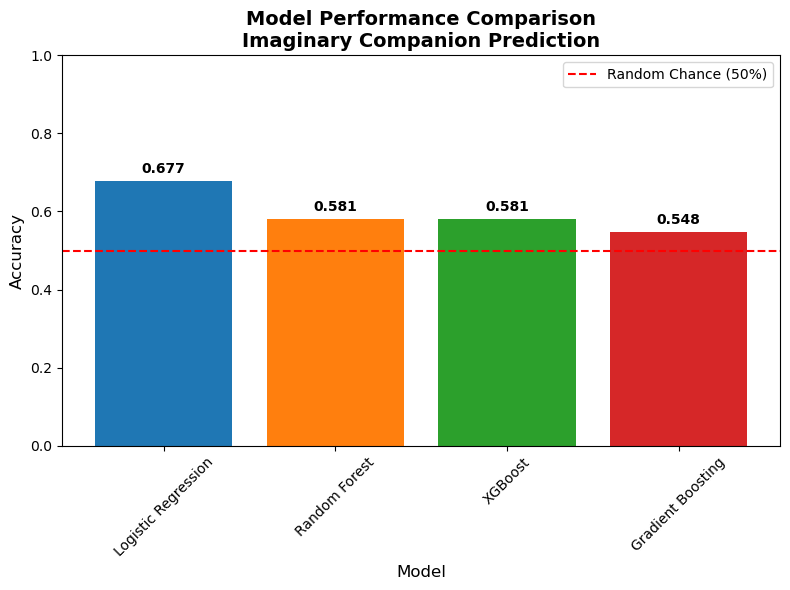

In [59]:
# Figure 1: Accuracy comparison bar chart
plt.figure(figsize=(8, 6))
plt.bar(results_df['Model'], results_df['Test Accuracy'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.axhline(y=0.5, color='red', linestyle='--', label='Random Chance (50%)')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Performance Comparison\nImaginary Companion Prediction', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.legend()
# Add value labels on bars
for i, v in enumerate(results_df['Test Accuracy']):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

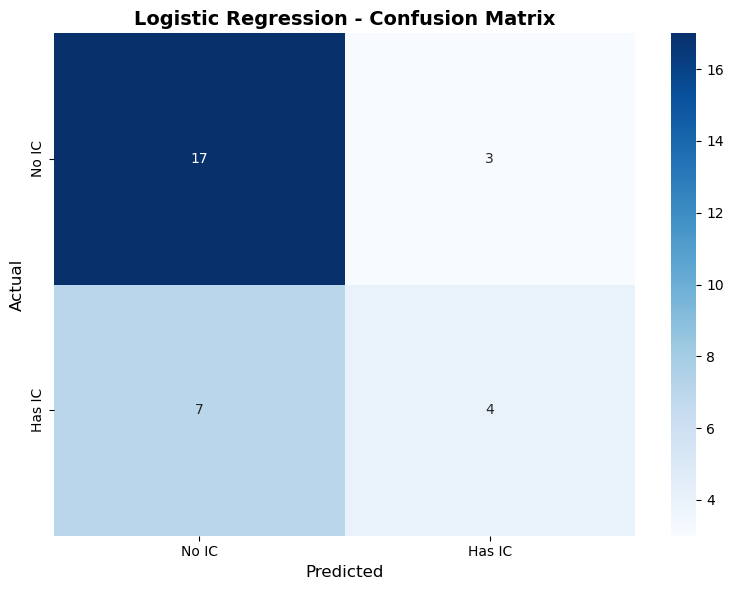

In [49]:
# Figure 2: Confusion matrix for the best model
if best_model_name == 'Logistic Regression':
    best_pred = y_pred_lr
elif best_model_name == 'Random Forest':
    best_pred = y_pred_rf
elif best_model_name == 'Gradient Boosting':
    best_pred = y_pred_gb
else:
    best_pred = y_pred_xgb

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No IC', 'Has IC'], 
            yticklabels=['No IC', 'Has IC'])
plt.title(f'{best_model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

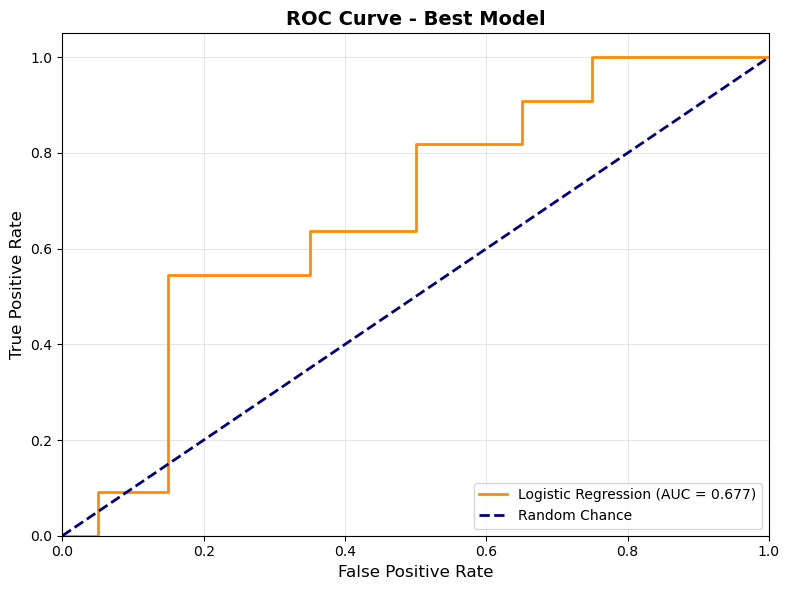

In [48]:
# Figure 3: ROC Curve for best model
plt.figure(figsize=(8, 6))
# Get prediction probabilities for best model
if best_model_name == 'Logistic Regression':
    y_proba = best_lr.predict_proba(X_test_scaled)[:, 1]
elif best_model_name == 'Random Forest':
    y_proba = best_rf.predict_proba(X_test_scaled)[:, 1]
elif best_model_name == 'Gradient Boosting':
    y_proba = best_gb.predict_proba(X_test_scaled)[:, 1]
elif best_model_name == 'SVM':
    y_proba = best_svm.predict_proba(X_test_scaled)[:, 1]
else:
    y_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'{best_model_name} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Best Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## CONCLUSION

### Best performing model: Logistic Regression, with a test accuracy of 67.7%.
### Logistic Regression outperformed more complex models like Random Forest, Gradient Boosting, and XGBoost, likely due to the relatively small dataset and linear relationships among features.
### Cross-validation scores were consistent with test accuracy, indicating good generalization and no significant overfitting.
### Feature importance analysis (for tree-based models) suggested that variables like loneliness, anxiety, and depression were moderately influential — aligning with psychological literature on social isolation and imaginative coping mechanisms.

## *Challenges & learnings*:
### Handling missing values and encoding categorical variables (gender, imaginary companion status) required careful preprocessing.
### Grid search and random search helped optimize hyperparameters efficiently.
### The dataset size (154 samples) limited model complexity; simpler models performed better.

## *What I’d improve next*:
### Collect more data (larger sample size) to improve model robustness.
### Include additional behavioral or demographic features (e.g., childhood environment, creativity scores).
### Try ensemble methods like Stacking or Voting Classifiers to combine model strengths.
### Deploy the best model as a simple web app (e.g., using Streamlit) for interactive predictions.

## *Why this matters*:
### Understanding psychological markers of imaginary companions can help in childhood development studies, therapeutic settings, and even AI companion design. This project shows how machine learning can bridge psychology and data science — a skill highly relevant for data science roles in healthcare, ed-tech, and human-computer interaction.